# EEG Data Analysis (Data Collection Experiments)

## Save All Event Markers

We want to save all the event markers from the data collection experiment along with their label and LSL time.

Loads the xdf file using pyxdf.

In [1]:
import pyxdf
import pandas as pd
import os

In [ ]:
# Config
n_experiment = 6
run = 'B'   # run in a single experiment session: '', 'A', 'B', etc.
data_path = f'experiment_data/exp{n_experiment}/'
output_file_name = f'mentalab_markers_exp{n_experiment}{run}.csv'
overwrite_existing = False

# Input: List of .xdf file paths
xdf_files = [
    data_path + f'exp{n_experiment}{run}.xdf',
]

# Concatenate all markers from all files
all_markers = []

for file_path in xdf_files:
    data, _ = pyxdf.load_xdf(file_path)
    
    for stream in data:
        if stream['info']['name'][0] == 'Explore_84A1_Marker':
            time_series = stream['time_series']
            time_stamps = stream['time_stamps']
            
            for i, marker_row in enumerate(time_series):
                label = marker_row[0] if isinstance(marker_row, (list, tuple)) else marker_row
                all_markers.append({'label': label, 'lsl_time': time_stamps[i]})

# Create DataFrame and export to CSV
df = pd.DataFrame(all_markers)
output_path = data_path + output_file_name

if overwrite_existing:
    df.to_csv(output_path, index=False)
    print(f"Exported {len(df)} markers to {output_file_name}")
else:
    # Try incrementing suffix until we find an available filename
    if os.path.exists(output_path):
        base_name = output_file_name.rsplit('.', 1)[0]
        extension = output_file_name.rsplit('.', 1)[1] if '.' in output_file_name else 'csv'
        counter = 1
        while os.path.exists(output_path):
            new_filename = f"{base_name}_{counter}.{extension}"
            output_path = data_path + new_filename
            counter += 1
        df.to_csv(output_path, index=False)
        print(f"Exported {len(df)} markers to {os.path.basename(output_path)}")
    else:
        df.to_csv(output_path, index=False)
        print(f"Exported {len(df)} markers to {output_file_name}")

Exported 46 markers to mentalab_markers_exp6B.csv


## Data Loading

Need access to data files: 
- `exp{n}.json`
- `all_markers_exp{n}.csv`

Place data files in directory: `/experiment_data/exp{n}/` and adjust "`n_experiment`" in the code.

### Functions

In [302]:
## Imports
import numpy as np
import json
import pandas as pd

In [303]:
def load_json(path):
    """Load JSON file from path."""
    with open(path, 'r') as f:
        return json.load(f)


In [304]:
def stream_to_dataframe(stream_data):
    """Convert a stream dict to a pandas DataFrame"""
    values = stream_data['Value']
    info = stream_data.get('Info', [])

    data_dict = {
        'TIMESTAMP': stream_data['TimeStamp'],
        'SAMPLING_RATE': stream_data['SamplingRate']
    }

    for i, name in enumerate(info):
        try:
            data_dict[name.upper()] = [value[i] for value in values]
        except (IndexError, TypeError):
            data_dict[name.upper()] = values

    return pd.DataFrame(data_dict)

In [305]:
def load_eeg_data(data_file, channel_mapping, verbose=True):
    """Load EEG data from JSON file and return DataFrame."""
    # Create DataFrames from JSON dict data
    json_data = load_json(data_file)

    eeg_df = stream_to_dataframe(json_data['EEG'])
    # marker_df = stream_to_dataframe(json_data['Marker'])

    # Apply EEG channel mapping to columns
    eeg_df.rename(columns=channel_mapping, inplace=True)

    # Zero EEG LSL timestamps to start at 0 (also use eeg_ts0 later for markers)
    if 'TIMESTAMP' in eeg_df.columns:
        eeg_df['TIMESTAMP'] = eeg_df['TIMESTAMP'].astype(float)
        eeg_ts0 = float(eeg_df['TIMESTAMP'].min())
        eeg_df['TIMESTAMP'] = eeg_df['TIMESTAMP'] - eeg_ts0

    if verbose:
        print("\nEEG channels:")
        print([c for c in eeg_df.columns if c not in ['TIMESTAMP','SAMPLING_RATE']][:10])
        print(eeg_df.head())

    return eeg_df, eeg_ts0

In [306]:
def load_event_markers(eeg_ts0, events_file, n_experiment, run="", verbose=True):
    """Load event markers from CSV and adjust timestamps."""
    # Load event markers and use FINAL timestamps
    events_df = pd.read_csv(events_file)

    events_df['TIMESTAMP'] = events_df['FINAL'].astype(float)
    
    # Remove null timestamps
    events_df = events_df.dropna(subset=['TIMESTAMP'])

    # Zero timestamps to match EEG zeroing
    events_df['TIMESTAMP'] = events_df['TIMESTAMP'] - eeg_ts0

    # Create 'id' column based on label naming convention
    def extract_id(label):
        """Extract condition ID (Fam/Unf) from label format 'sw_{name}'"""
        if isinstance(label, str) and label.startswith('sw_'):
            name = label[3:]  # Remove 'sw_' prefix
            if name.startswith('F'):
                return 'Fam'
            elif name.startswith('U'):
                return 'Unf'
            elif name.startswith('M'):
                return 'Mov'
        return None

    events_df['ID'] = events_df['LABEL'].apply(extract_id)

    if verbose:
        print(f"Loaded {len(events_df)} markers")
        print("\nEvents:")
        print(events_df.head())
    
    return events_df

### Run

In [307]:
## Data Config
n_experiment = 3
run = ""   # run in a single experiment session: '', 'A', 'B', etc.

data_dir = f'experiment_data/exp{n_experiment}/'
data_file = data_dir + f'exp{n_experiment}{run}.json'

events_file = data_dir + f'all_markers_exp{n_experiment}{run}.csv'

channel_mapping = {
    'CH1': 'Cz',
    'CH2': 'Pz',
    'CH3': 'T7',
    'CH4': 'T8',
    'CH5': 'P7',
    'CH6': 'P8',
    'CH7': 'O1',
    'CH8': 'O2'
}

In [308]:
## Load EEG Data
eeg_df, eeg_ts0 = load_eeg_data(data_file, channel_mapping)


EEG channels:
['Cz', 'Pz', 'T7', 'T8', 'P7', 'P8', 'O1', 'O2']
   TIMESTAMP  SAMPLING_RATE             Cz            Pz            T7  \
0   0.000000            251  104553.953125  79541.257812  77251.828125   
1   0.003989            251  104552.281250  79521.953125  77249.296875   
2   0.007977            251  104551.093750  79510.601562  77278.429688   
3   0.011966            251  104549.562500  79508.843750  77280.289062   
4   0.015955            251  104544.367188  79521.000000  77243.718750   

             T8            P7            P8            O1            O2  
0  88897.140625  83966.171875  82832.539062  70448.171875  96425.210938  
1  88906.578125  83965.929688  82834.210938  70421.179688  96413.773438  
2  88858.093750  83980.046875  82823.289062  70477.398438  96404.898438  
3  88867.578125  83981.906250  82814.750000  70525.851562  96397.078125  
4  88890.750000  83960.453125  82834.640625  70461.812500  96406.140625  


Load manually-computed timestamps to use for analysis. 

Zero with the same difference as the EEG data.

In [309]:
## Load event marker timestamps
events_df = load_event_markers(eeg_ts0, events_file, n_experiment, run)

Loaded 80 markers

Events:
     LABEL     MENTALAB        FINAL   TIMESTAMP   ID
3  sw_F1T1  540014.8629  540015.3801   76.172299  Fam
4    sw_U1  540046.2261  540046.6129  107.405099  Unf
5  sw_F2T1  540067.7601  540067.9479  128.740099  Fam
6    sw_U2  540082.2010  540081.9834  142.775599  Unf
7    sw_U3  540093.9919  540094.1362  154.928399  Unf


## 

## EEG Preprocessing

Preprocess EEG to get the data to clean the signal and obtain ERP.

**Preprocessing Pipeline:**
1. Filter Continuous EEG Data (1-40 Hz bandpass + 60/120 Hz notch)
2. (Optional) Re-reference with CAR
3. Epoch EEG data to Events
4. Perform ICA for artifact removal (with temporary 2 Hz high-pass filter)
   - 4a: Fit ICA and inspect components
   - 4b: Select components to exclude
   - 4c: Apply ICA to remove artifacts
5. Re-reference to REST (infinite reference using forward model)
6. Baseline correction: subtract baseline mean from each epoch (from before movement occurs)
7. Reject and substitute channels per trial (based on peak-to-peak amplitude)

**Note:** Code is organized into preprocessing functions followed by a "Run" section for execution with separate cells for each step.

#### Imports and Setup

In [310]:
import mne
import numpy as np
import pandas as pd

In [311]:
# MNE/Jupyter plot setup
%matplotlib inline
# %matplotlib qt
# %gui qt
# mne.viz.set_3d_backend("notebook")
mne.viz.set_browser_backend("matplotlib")

'matplotlib'

##### GPU Acceleration

For GPU acceleration, run in terminal:

```powershell
pip install cupy
MNE_USE_CUDA=true python -c "import mne; mne.cuda.init_cuda(verbose=True)"
```

In [312]:
# Enable CUDA in MNE
mne.utils.set_config('MNE_USE_CUDA', 'true')
# Verify CUDA is enabled
mne.cuda.init_cuda(verbose=True)

### Preprocessing Functions

#### Prepare EEG

In [313]:
def prepare_eeg_data(eeg_df, ch_names):
    """
    Prepare raw EEG data from DataFrame and create MNE Raw object.
    
    Parameters
    ----------
    eeg_df : pd.DataFrame
        DataFrame containing EEG data with columns for each channel and TIMESTAMP, SAMPLING_RATE
    ch_names : list of str
        Desired channel names in order (e.g., ["Cz", "Pz", "F7", "F8", "P7", "P8", "O1", "O2"])
    
    Returns
    -------
    raw : mne.io.Raw
        MNE RawArray object with montage set
    """
    print("="*60)
    print("Preparing EEG Data")
    print("="*60)
    
    # Current EEG columns
    meta_cols = {"TIMESTAMP", "SAMPLING_RATE"}
    eeg_cols_current = [c for c in eeg_df.columns if c not in meta_cols]
    
    if len(eeg_cols_current) != len(ch_names):
        print(
            f"Warning: expected {len(ch_names)} EEG channels, found {len(eeg_cols_current)}: {eeg_cols_current}"
        )
    
    # Prepare numeric data matrix (n_channels x n_times) for MNE RawArray
    # Coerce to numeric and replace NaNs with 0 for stability
    eeg_numeric = eeg_df[eeg_cols_current].apply(pd.to_numeric, errors='coerce')
    data = eeg_numeric.to_numpy().T.astype(float, copy=False)
    np.nan_to_num(data, copy=False)
    
    # Convert from microvolts to volts (MNE expects volts)
    data = data * 1e-6
    
    # Sampling frequency
    sfreq = float(eeg_df["SAMPLING_RATE"].iloc[0]) if "SAMPLING_RATE" in eeg_df.columns else None
    
    # Create MNE Info and RawArray using desired channel labels (truncate in case of mismatch)
    desired_ch_names = ch_names[: data.shape[0]]
    info = mne.create_info(ch_names=desired_ch_names, sfreq=sfreq, ch_types='eeg')
    raw = mne.io.RawArray(data, info, verbose=False)
    
    # Apply a standard montage that includes these channels
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, match_case=False, on_missing='ignore')
    
    print(raw)
    print("Channels:", raw.ch_names)
    print("Sampling rate:", raw.info['sfreq'])
    print("Data range (V):", f"{data.min():.2e} to {data.max():.2e}")
    print()
    
    return raw

#### Filtering

In [314]:
def add_arrows(axes):
    """Add arrows to PSD plots at 60 Hz and its harmonics without indexing past data range."""
    harmonics = (60, 120, 180, 240)
    for ax in axes:
        # Choose the plotted line with the most points to derive freqs/psd safely
        lines = [ln for ln in ax.lines if hasattr(ln, "get_xdata")]
        if not lines:
            continue
        line = max(lines, key=lambda ln: len(ln.get_xdata()))
        freqs = np.asarray(line.get_xdata())
        psds = np.asarray(line.get_ydata())
        if freqs.size == 0 or psds.size == 0:
            continue

        fmax_plot = float(freqs[-1])
        for freq in harmonics:
            # Skip harmonics outside the plotted frequency range
            if freq > fmax_plot:
                continue
            # Find insertion index and clamp to valid range
            idx = int(np.searchsorted(freqs, freq, side="left"))
            if idx >= freqs.size:
                idx = freqs.size - 1
            if idx < 0:
                idx = 0

            # Robust neighborhood for peak arrow height
            i0 = max(0, idx - 4)
            i1 = min(psds.size, idx + 5)
            if i0 >= i1:
                y = float(psds[idx])
            else:
                y = float(psds[i0:i1].max())

            # Draw a short downward arrow
            ax.arrow(
                x=float(freqs[idx]),
                y=y + 18,
                dx=0,
                dy=-12,
                color="red",
                width=0.1,
                head_width=3,
                length_includes_head=True,
            )

In [315]:
def filter_continuous_eeg(raw, l_freq=1.0, h_freq=40.0, notch_freqs=[60.0, 120.0], show_plots=True):
    """
    Apply bandpass and notch filters to continuous EEG data.
    
    Parameters
    ----------
    raw : mne.io.Raw
        Raw EEG data
    l_freq : float
        Low-pass frequency for bandpass filter (Hz)
    h_freq : float
        High-pass frequency for bandpass filter (Hz)
    notch_freqs : list of float
        Frequencies to notch filter (Hz) - typically power line noise
    
    Returns
    -------
    raw_filt : mne.io.Raw
        Filtered raw EEG data
    """
    print("="*60)
    print("Filtering Continuous EEG Data")
    print("="*60)
    
    raw_filt = raw.copy().load_data()
    
    # Bandpass filter
    print(f"Applying bandpass filter: {l_freq}-{h_freq} Hz")
    raw_filt.filter(l_freq, h_freq)
    
    # Notch filter for power line noise
    if notch_freqs:
        print(f"Applying notch filter at: {notch_freqs} Hz")
        raw_filt.notch_filter(freqs=notch_freqs)
    
    print(f"Filtered data: {raw_filt}")
    print()
    
    if show_plots:
        # Raw w/ arrows - Plot PSD and annotate
        fig = raw.compute_psd(fmax=124).plot(
            average=True, amplitude=False, picks="data", exclude="bads"
        )
        add_arrows(fig.axes[:2])
        
        # Filtered
        fig = raw_filt.compute_psd(fmax=124).plot(
            average=True, amplitude=False, picks="data", exclude="bads"
        )
    
    return raw_filt

#### CAR Re-reference

In [316]:
def apply_car_reference(raw, avg_channels=None):
    """
    Apply Common Average Reference (CAR) re-referencing.
    
    Parameters
    ----------
    raw : mne.io.Raw
        Raw EEG data
    avg_channels : list of str, optional
        Channels to use for averaging. If None, uses all channels.
        Recommended: select 2 best channels (low impedance midline & parieto-occipital)
    
    Returns
    -------
    raw_reref : mne.io.Raw
        Re-referenced raw EEG data
    """
    print("="*60)
    print("Re-referencing with CAR")
    print("="*60)
    
    raw_reref = raw.copy()
    
    if avg_channels is not None:
        # Map to actual channel names (case-insensitive)
        ch_upper_map = {ch.upper(): ch for ch in raw_reref.ch_names}
        picks_in_avg = [ch_upper_map[ch.upper()] for ch in avg_channels if ch.upper() in ch_upper_map]
        
        if not picks_in_avg:
            raise ValueError(f"None of the specified channels {avg_channels} found in data")
        
        print(f"Applying CAR with {len(picks_in_avg)} channels: {picks_in_avg}")
        raw_reref, ref_data = mne.set_eeg_reference(raw_reref, ref_channels=picks_in_avg, projection=False)
        
        # Sanity check
        avg_std = float(raw_reref.get_data(picks=picks_in_avg).mean(axis=0).std())
        print(f"Post-ref mean(trace) std: {avg_std * 1e6:.2f} μV")
    else:
        print("Applying CAR with all channels")
        raw_reref, ref_data = mne.set_eeg_reference(raw_reref, ref_channels='average', projection=False)
    
    print()
    return raw_reref

#### Epoch EEG Data

In [317]:
def epoch_eeg_data(raw, events_df, eeg_df, event_id={'Fam': 1, 'Unf': 2, 'Mov': 3}, 
                   epoch_dur=[-1.5, 1.5], picks=None):
    """
    Create epochs from continuous EEG data based on event markers.
    
    Parameters
    ----------
    raw : mne.io.Raw
        Raw EEG data
    events_df : pd.DataFrame
        DataFrame containing event markers with 'TIMESTAMP' and 'ID' columns
    eeg_df : pd.DataFrame
        DataFrame containing EEG timestamps
    event_id : dict
        Mapping from event labels to event codes (movement trials are optional)
    epoch_dur : list of float
        Epoch duration as [tmin, tmax] in seconds relative to event
    picks : list of str, optional
        Channels to include in epochs
    
    Returns
    -------
    epochs : mne.Epochs
        Epoched EEG data
    """
    print("="*60)
    print("Epoching EEG Data to Events")
    print("="*60)
    
    ts = eeg_df['TIMESTAMP'].to_numpy(dtype=float)
    
    def nearest_indices(ts_array, targets):
        idxs = []
        for t in targets:
            j = int(np.argmin(np.abs(ts_array - float(t))))
            idxs.append(j)
        return np.asarray(idxs, dtype=int)
    
    # Check which event IDs from event_id actually exist in the data
    available_event_ids = {k: v for k, v in event_id.items() 
                          if k in events_df['ID'].values}
    
    if not available_event_ids:
        raise ValueError("No matching events found in events_df for the provided event_id mapping")
    
    # Print info about which events are being used
    missing_events = set(event_id.keys()) - set(available_event_ids.keys())
    if missing_events:
        print(f"Note: The following event types are not present in the data and will be skipped: {missing_events}")
    
    # Filter for valid events
    valid_events = events_df[events_df['ID'].isin(available_event_ids.keys())].dropna(subset=['TIMESTAMP', 'ID']).copy()
    
    # Map ID to event codes
    valid_events['event_code'] = valid_events['ID'].map(available_event_ids)
    
    # Convert timestamps to sample indices
    sample_indices = nearest_indices(ts, valid_events['TIMESTAMP'].to_numpy())
    
    # Build MNE events array
    events_mne = np.column_stack([
        sample_indices,
        np.zeros(len(sample_indices), dtype=int),
        valid_events['event_code'].to_numpy()
    ])
    
    # Sort by sample index
    events_mne = events_mne[np.argsort(events_mne[:, 0])]
    
    # Count events per condition
    for label, code in available_event_ids.items():
        n = int((valid_events['ID'] == label).sum())
        print(f"  {label}: {n} events")
    print(f"  Total: {len(events_mne)} events")
    
    # Create epochs
    print(f"Creating epochs from {epoch_dur[0]} to {epoch_dur[1]} s")
    epochs = mne.Epochs(
        raw,
        events=events_mne,
        event_id=available_event_ids,  # Use only available event IDs
        picks=picks,
        tmin=epoch_dur[0],
        tmax=epoch_dur[1],
        baseline=None,  # No baseline correction yet
        preload=True,
        reject=None,
        flat=None
    )
    
    print(f"Created {len(epochs)} epochs")
    print()
    
    return epochs

#### ICA Artifact Removal

In [318]:
def fit_ica(epochs, n_components=None, random_state=42, temp_highpass_freq=2.0):
    """
    Fit ICA on epoched data for artifact removal.
    
    Applies a temporary high-pass filter at ~2 Hz before ICA to reduce sensitivity
    to intended free-viewing movement artifacts.
    
    Parameters
    ----------
    epochs : mne.Epochs
        Epoched EEG data
    n_components : int, optional
        Number of ICA components to compute. If None, uses min(n_channels, n_samples)
    random_state : int
        Random seed for ICA reproducibility
    temp_highpass_freq : float
        Temporary high-pass filter frequency (Hz) applied before ICA
    
    Returns
    -------
    ica : mne.preprocessing.ICA
        Fitted ICA object
    epochs_for_ica : mne.Epochs
        Epochs with temporary high-pass filter (for plotting sources)
    """
    print("="*60)
    print("Fitting ICA for Artifact Removal")
    print("="*60)
    
    # Create a copy for ICA processing with temporary high-pass filter
    print(f"Applying temporary high-pass filter at {temp_highpass_freq} Hz for ICA")
    epochs_for_ica = epochs.copy().filter(l_freq=temp_highpass_freq, h_freq=None)
    
    # Set up ICA
    if n_components is None:
        n_components = min(len(epochs_for_ica.ch_names), len(epochs_for_ica))
    
    print(f"Fitting ICA with {n_components} components...")
    ica = mne.preprocessing.ICA(
        n_components=n_components,
        random_state=random_state,
        max_iter='auto'
    )
    
    # Fit ICA on the filtered epochs
    ica.fit(epochs_for_ica)
    print(f"ICA fitted on {len(epochs_for_ica)} epochs")
    print("\nNext: Inspect components and select which to exclude")
    print("Use: plot_ica_components(ica, epochs_for_ica)")
    print()
    
    return ica, epochs_for_ica

In [319]:
def plot_ica_components(ica, epochs_for_ica, components_to_plot=[0, 1], plot_ica_components=True, plot_ica_sources=True, plot_ica_properties=True):
    """
    Plot ICA components and their sources for inspection.
    
    Parameters
    ----------
    ica : mne.preprocessing.ICA
        Fitted ICA object
    epochs_for_ica : mne.Epochs
        Epochs used for ICA fitting (with temporary high-pass filter)
    """
    print("="*60)
    print("Plotting ICA Components for Inspection")
    print("="*60)
    
    # Plot ICA components
    if plot_ica_components:
        print("Plotting ICA components...")
        ica.plot_components()
    
    # Plot sources for visual inspection
    if plot_ica_sources:
        print("Plotting ICA sources...")
        ica.plot_sources(epochs_for_ica, picks=components_to_plot)
    
    # Plot properties of first two components
    if plot_ica_properties:
        print("Plotting ICA properties...")
        ica.plot_properties(epochs_for_ica, picks=components_to_plot)
    
    
    print("Inspect the plots to identify artifact components.")
    print("Set ica.exclude = [list of component indices] to exclude them.")
    print()

In [320]:
def apply_ica(epochs, ica):
    """
    Apply ICA artifact removal to epochs.
    
    Parameters
    ----------
    epochs : mne.Epochs
        Epoched EEG data (original, not temporarily filtered)
    ica : mne.preprocessing.ICA
        Fitted ICA object with exclude list set
    
    Returns
    -------
    epochs_clean : mne.Epochs
        Epochs with ICA artifacts removed
    """
    print("="*60)
    print("Applying ICA to Remove Artifacts")
    print("="*60)
    
    print(f"Excluding components: {ica.exclude}")
    if not ica.exclude:
        print("WARNING: No components marked for exclusion!")
    
    # Apply ICA to the original (non-temporarily-filtered) epochs
    print("Applying ICA to remove artifacts from original epochs...")
    epochs_clean = epochs.copy()
    ica.apply(epochs_clean)
    
    print(f"ICA artifact removal complete")
    print()
    
    return epochs_clean

#### Apply REST

In [321]:
def apply_rest_reference(epochs, forward=None):
    """
    Apply REST (Reference Electrode Standardization Technique) re-referencing.
    
    REST is an infinite reference technique that estimates the potential at infinity
    using a forward model and spherical spline interpolation.
    
    Parameters
    ----------
    epochs : mne.Epochs
        Epoched EEG data with montage set
    forward : mne.Forward, optional
        Forward solution for REST. If None, will be computed automatically.
    
    Returns
    -------
    epochs_rest : mne.Epochs
        Epochs re-referenced to REST
    forward : mne.Forward
        Forward solution used for REST
    """
    print("="*60)
    print("Re-referencing to REST (Infinite Reference)")
    print("="*60)
    
    # Check if montage is set
    if epochs.get_montage() is None:
        raise ValueError("Montage must be set before applying REST. Use epochs.set_montage()")
    
    print("Applying REST re-referencing...")
    
    # Create forward model if not provided (see mne.set_eeg_reference docs)
    if forward is None:
        print("Creating forward model for REST...")
        sphere = mne.make_sphere_model("auto", "auto", epochs.info)
        src = mne.setup_volume_source_space(sphere=sphere, exclude=30.0, pos=15.0)
        forward = mne.make_forward_solution(epochs.info, trans=None, src=src, bem=sphere)
        print("Forward model created")
    
    # Apply REST reference
    epochs_rest = epochs.copy()
    epochs_rest.set_eeg_reference('REST', forward=forward)
    
    print("REST re-referencing complete")
    print()
    
    return epochs_rest, forward

#### Baseline Correction

In [322]:
def apply_baseline_correction(epochs, baseline_window=None):
    """
    Apply baseline correction by subtracting the mean of the baseline period.
    
    Parameters
    ----------
    epochs : mne.Epochs
        Epoched EEG data
    baseline_window : tuple of float, optional
        Baseline time window (tmin, tmax) in seconds.
        If None, uses the entire pre-stimulus period.
    
    Returns
    -------
    epochs_baseline : mne.Epochs
        Baseline-corrected epochs
    """
    print("="*60)
    print("Baseline Correction")
    print("="*60)
    
    if baseline_window is None:
        baseline_window = (None, 0)
        print("Applying baseline correction using entire pre-stimulus period")
    else:
        print(f"Applying baseline correction using window: {baseline_window[0]} to {baseline_window[1]} s")
    
    epochs_baseline = epochs.copy()
    epochs_baseline.apply_baseline(baseline=baseline_window)
    
    print("Baseline correction complete")
    print()
    
    return epochs_baseline

#### Trial Rejection and Bad Channel Marking

In [323]:
def reject_bad_trials(epochs, amp_thresh=200e-6, baseline_window=[-1, -0.7], 
                      erp_window=[0.1, 0.65], n250_channels=['T7', 'T8', 'P7', 'P8', 'O1', 'O2'],
                      p300_channels=['Cz', 'Pz'], rejection_threshold=0.5):
    """
    Reject trials based on peak-to-peak amplitude in baseline and ERP windows.
    
    If more than half of the channels in a component (N250 or P300) are bad,
    reject the whole trial. Otherwise, keep the trial and mark bad channels for later
    substitution during feature extraction.
    
    Parameters
    ----------
    epochs : mne.Epochs
        Epoched EEG data
    amp_thresh : float
        Peak-to-peak amplitude threshold in volts
    baseline_window : list of float
        Baseline time window [tmin, tmax] in seconds
    erp_window : list of float
        ERP time window [tmin, tmax] in seconds
    n250_channels : list of str
        Channels in N250 component
    p300_channels : list of str
        Channels in P300 component
    rejection_threshold : float
        Fraction of channels that must be bad to reject trial (default 0.5 = 50%)
    
    Returns
    -------
    epochs_clean : mne.Epochs
        Epochs with bad trials removed
    bad_channels_per_trial : dict
        Dictionary mapping trial index to list of bad channels
    """
    print("="*60)
    print("Rejecting and Substituting Channels per Trial")
    print("="*60)
    
    print(f"Rejection threshold: {amp_thresh*1e6:.0f} µV")
    print(f"Baseline window: {baseline_window}")
    print(f"ERP window: {erp_window}")
    print(f"Trial rejection if >{rejection_threshold*100:.0f}% of component channels are bad")
    print()
    
    # Get epoch labels
    inv_event_id = {v: k for k, v in epochs.event_id.items()}
    labels = [inv_event_id.get(code, str(code)) for code in epochs.events[:, 2]]
    
    X = epochs.get_data()  # (n_epochs, n_channels, n_times)
    ch_names = epochs.ch_names
    
    # Map channel names (case-insensitive)
    upper_map = {ch.upper(): i for i, ch in enumerate(ch_names)}
    
    # Get indices for component channels
    n250_idx = [upper_map[c.upper()] for c in n250_channels if c.upper() in upper_map]
    p300_idx = [upper_map[c.upper()] for c in p300_channels if c.upper() in upper_map]
    
    print(f"N250 channels ({len(n250_idx)}): {[ch_names[i] for i in n250_idx]}")
    print(f"P300 channels ({len(p300_idx)}): {[ch_names[i] for i in p300_idx]}")
    print()
    
    # Get time indices for windows
    i0b, i1b = epochs.time_as_index(baseline_window)
    i0b, i1b = (i0b, i1b) if i0b <= i1b else (i1b, i0b)
    
    i0e, i1e = epochs.time_as_index(erp_window)
    i0e, i1e = (i0e, i1e) if i0e <= i1e else (i1e, i0e)
    
    # Compute peak-to-peak per channel in each window
    ptp_baseline = np.ptp(X[:, :, i0b:i1b + 1], axis=2)  # (n_epochs, n_channels)
    ptp_erp = np.ptp(X[:, :, i0e:i1e + 1], axis=2)
    
    # Identify bad channels per trial
    bad_mask = (ptp_baseline > amp_thresh) | (ptp_erp > amp_thresh)  # (n_epochs, n_channels)
    
    # Determine which trials to reject based on component-wise thresholds
    trials_to_reject = []
    bad_channels_per_trial = {}
    
    for epoch_idx in range(len(epochs)):
        bad_ch_idx = np.flatnonzero(bad_mask[epoch_idx])
        bad_ch_names = [ch_names[i] for i in bad_ch_idx]
        
        if len(bad_ch_idx) > 0:
            bad_channels_per_trial[epoch_idx] = bad_ch_names
        
        # Check N250 component
        n250_bad = sum(1 for i in n250_idx if bad_mask[epoch_idx, i])
        n250_bad_ratio = n250_bad / len(n250_idx) if len(n250_idx) > 0 else 0
        
        # Check P300 component
        p300_bad = sum(1 for i in p300_idx if bad_mask[epoch_idx, i])
        p300_bad_ratio = p300_bad / len(p300_idx) if len(p300_idx) > 0 else 0
        
        # Reject if either component exceeds threshold
        if n250_bad_ratio > rejection_threshold or p300_bad_ratio > rejection_threshold:
            trials_to_reject.append(epoch_idx)
    
    print(f"Trials to reject: {len(trials_to_reject)} of {len(epochs)}")
    print(f"Trials with bad channels (but not rejected): {len(bad_channels_per_trial) - len(trials_to_reject)}")
    
    # Report details of rejected trials
    if trials_to_reject:
        print("\nRejected trials:")
        for idx in trials_to_reject:
            label = labels[idx] if idx < len(labels) else "unknown"
            bad_chs = bad_channels_per_trial.get(idx, [])
            
            n250_bad = sum(1 for ch in bad_chs if ch.upper() in [c.upper() for c in n250_channels])
            p300_bad = sum(1 for ch in bad_chs if ch.upper() in [c.upper() for c in p300_channels])
            
            print(f"  Trial {idx} ({label}): {len(bad_chs)} bad channels | "
                  f"N250: {n250_bad}/{len(n250_idx)} | P300: {p300_bad}/{len(p300_idx)}")
    
    # Count bad channels across all trials
    channel_bad_count = {}
    for trial_idx, bad_chs in bad_channels_per_trial.items():
        for ch in bad_chs:
            channel_bad_count[ch] = channel_bad_count.get(ch, 0) + 1
    
    # Print per-channel bad channel statistics (omitting channels with zero)
    if channel_bad_count:
        print("\nBad channels across trials:")
        for ch in sorted(channel_bad_count.keys()):
            count = channel_bad_count[ch]
            if count > 0:
                print(f"  {ch}: {count} trials")
    
    # Drop bad epochs
    epochs_clean = epochs.copy()
    epochs_clean.drop(trials_to_reject)
    
    print(f"\nFinal: {len(epochs_clean)} good trials remaining")
    print()
    
    return epochs_clean, bad_channels_per_trial

### Run Preprocessing

Execute the full preprocessing pipeline by calling the functions defined above.

Adjust parameters for the experiment in question.

In [324]:
## Preprocessing Configuration
preprocessing_config = {
    # Prepare EEG Data
    'prepare': {
        'ch_names': ['Cz', 'Pz', 'T7', 'T8', 'P7', 'P8', 'O1', 'O2']  # Channel names in order
    },
    
    # Step 1: Filtering
    'filter': {
        'l_freq': 1,        # Low-pass frequency (Hz)
        'h_freq': 40.0,       # High-pass frequency (Hz)
        'notch_freqs': [60.0, 120.0]  # Power line noise frequencies
    },
    
    # Step 2: CAR Re-referencing (optional)
    'car': {
        'apply': False,  # Set to False to skip CAR
        'avg_channels': ["F7", "F8"]  # Select non-analysis channels
    },
    
    # Step 3: Epoching
    'epoching': {
        'event_id': {'Fam': 1, 'Unf': 2, 'Mov': 3},
        'epoch_dur': [-1.5, 1.5],  # [tmin, tmax] in seconds
        'picks': ['Cz', 'Pz', 'T7', 'T8', 'P7', 'P8', 'O2']  # Channels to include
    },
    
    # Step 4: ICA
    'ica': {
        'apply': True,  # Set to False to skip ICA
        'n_components': None,  # None = auto
        'random_state': 42,
        'temp_highpass_freq': 2.0,  # Temporary high-pass for ICA
        'exclude_components': []  # List of component indices to exclude (e.g., [0, 1, 2])
    },
    
    # Step 5: REST Re-referencing
    'rest': {
        'apply': True  # Set to False to skip REST
    },
    
    # Step 6: Baseline Correction
    'baseline': {
        'window': [-1, -0.7]  # Baseline time window (None, 0) for entire pre-stimulus
    },
    
    # Step 7: Trial Rejection
    'rejection': {
        'amp_thresh': 200e-6,  # ptp rejection amplitude in volts
        'baseline_window': [-1, -0.7],
        'erp_window': [0.1, 0.65],
        'n250_channels': ['P7', 'P8', 'O1', 'O2'],
        'p300_channels': ['Cz', 'Pz'],
        'rejection_threshold': 0.5  # Reject if >50% of component channels are bad
    },
    
    # File saving
    'save': {
        'save_epochs': True,
        'filename': data_dir + f"eeg_exp{n_experiment}{run}_preprocessed-epo.fif",
        'save_bad_channels': True,
        'bad_channels_filename': data_dir + f"exp{n_experiment}{run}_bad_channels_per_trial.csv"
    }
}

print("Preprocessing configuration loaded")
print(f"Output file: {preprocessing_config['save']['filename']}")

Preprocessing configuration loaded
Output file: experiment_data/exp3/eeg_exp3_preprocessed-epo.fif


In [325]:
## Prepare EEG Data
raw = prepare_eeg_data(eeg_df, preprocessing_config['prepare']['ch_names'])
print(f"Raw EEG data prepared: {len(raw.ch_names)} channels")
print(f"Sampling rate: {raw.info['sfreq']} Hz")
print(f"Duration: {raw.times[-1]:.2f} seconds")

Preparing EEG Data
<RawArray | 8 x 469712 (1871.4 s), ~28.7 MiB, data loaded>
Channels: ['Cz', 'Pz', 'T7', 'T8', 'P7', 'P8', 'O1', 'O2']
Sampling rate: 251.0
Data range (V): -3.97e-01 to 2.11e-01

Raw EEG data prepared: 8 channels
Sampling rate: 251.0 Hz
Duration: 1871.36 seconds


Filtering Continuous EEG Data
Applying bandpass filter: 1-40.0 Hz
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 829 samples (3.303 s)



Applying notch filter at: [60.0, 120.0] Hz
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1657 samples (6.602 s)

Filtered data: <RawArray | 8 x 469712 (1871.4 s), ~28.7 MiB, data loaded>

Effective window size : 8.159 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.159 (s)
Plotting power spectral density (dB=True).


c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\.venv_eeg\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\.venv_eeg\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


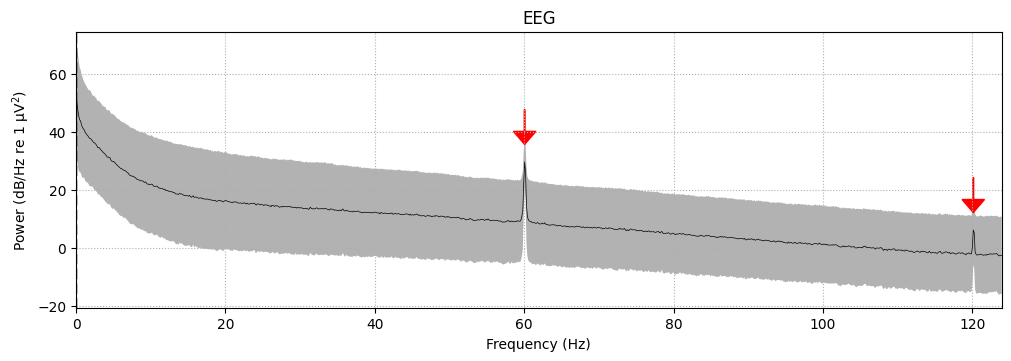

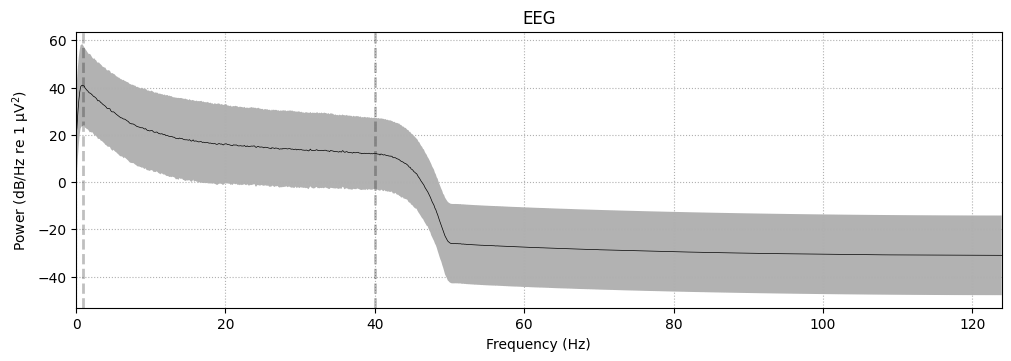

In [326]:
## Step 1: Filter Continuous EEG Data
raw_filt = filter_continuous_eeg(
    raw,
    l_freq=preprocessing_config['filter']['l_freq'],
    h_freq=preprocessing_config['filter']['h_freq'],
    notch_freqs=preprocessing_config['filter']['notch_freqs']
)

In [327]:
## Step 2: Re-reference with CAR (optional)
if preprocessing_config['car']['apply']:
    raw_reref = apply_car_reference(
        raw_filt,
        avg_channels=preprocessing_config['car']['avg_channels']
    )
else:
    print("="*60)
    print("CAR Re-referencing - SKIPPED")
    print("="*60 + "\n")
    raw_reref = raw_filt

CAR Re-referencing - SKIPPED



In [328]:
## Step 3: Epoch EEG Data to Events
epochs = epoch_eeg_data(
    raw_reref,
    events_df=events_df,
    eeg_df=eeg_df,
    event_id=preprocessing_config['epoching']['event_id'],
    epoch_dur=preprocessing_config['epoching']['epoch_dur'],
    picks=preprocessing_config['epoching']['picks']
)

Epoching EEG Data to Events
Note: The following event types are not present in the data and will be skipped: {'Mov'}
  Fam: 40 events
  Unf: 40 events
  Total: 80 events
Creating epochs from -1.5 to 1.5 s
Not setting metadata
80 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 80 events and 753 original time points ...
0 bad epochs dropped
Created 80 epochs

80 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 80 events and 753 original time points ...
0 bad epochs dropped
Created 80 epochs



In [349]:
## Reset epochs to pre-ICA
if 'epochs_pre_ica' in globals():
    epochs = epochs_pre_ica.copy()

In [350]:
## Step 4a: Fit ICA
if preprocessing_config['ica']['apply']:
    ica, epochs_for_ica = fit_ica(
        epochs,
        n_components=preprocessing_config['ica']['n_components'],
        random_state=preprocessing_config['ica']['random_state'],
        temp_highpass_freq=preprocessing_config['ica']['temp_highpass_freq']
    )
else:
    print("="*60)
    print("STEP 4: ICA Artifact Removal - SKIPPED")
    print("="*60 + "\n")
    ica = None
    epochs_for_ica = None

Fitting ICA for Artifact Removal
Applying temporary high-pass filter at 2.0 Hz for ICA
Setting up high-pass filter at 2 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 2.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 1.00 Hz)
- Filter length: 415 samples (1.653 s)

Fitting ICA with 7 components...
Fitting ICA to data using 7 channels (please be patient, this may take a while)
Selecting by number: 7 components
Fitting ICA took 0.2s.
ICA fitted on 80 epochs

Next: Inspect components and select which to exclude
Use: plot_ica_components(ica, epochs_for_ica)



C:\Users\doubl\AppData\Local\Temp\ipykernel_13428\2165756743.py:46: RuntimeWarning: Using n_components=7 (resulting in n_components_=7) may lead to an unstable mixing matrix estimation because the ratio between the largest (7) and smallest (2e-06) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 6
  ica.fit(epochs_for_ica)


Plotting ICA Components for Inspection
Plotting ICA components...


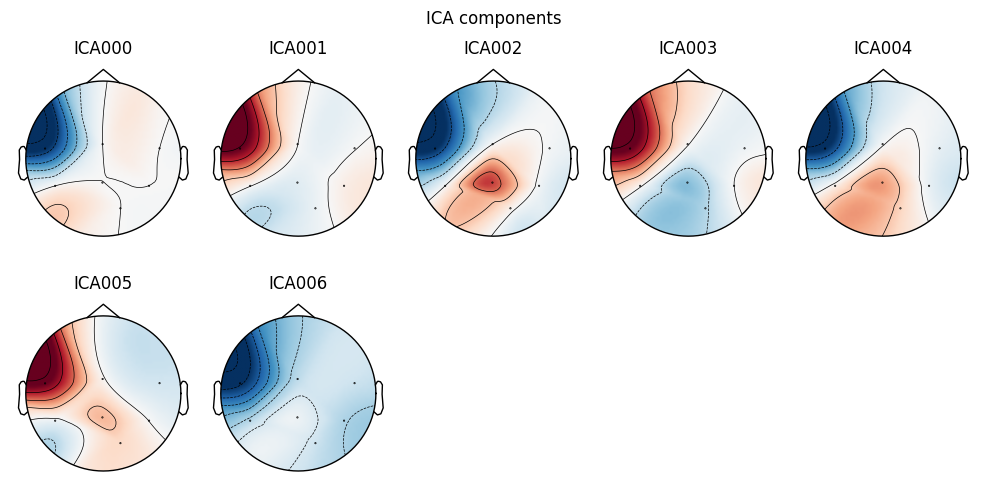

Plotting ICA sources...
Not setting metadata
80 matching events found
No baseline correction applied
0 projection items activated


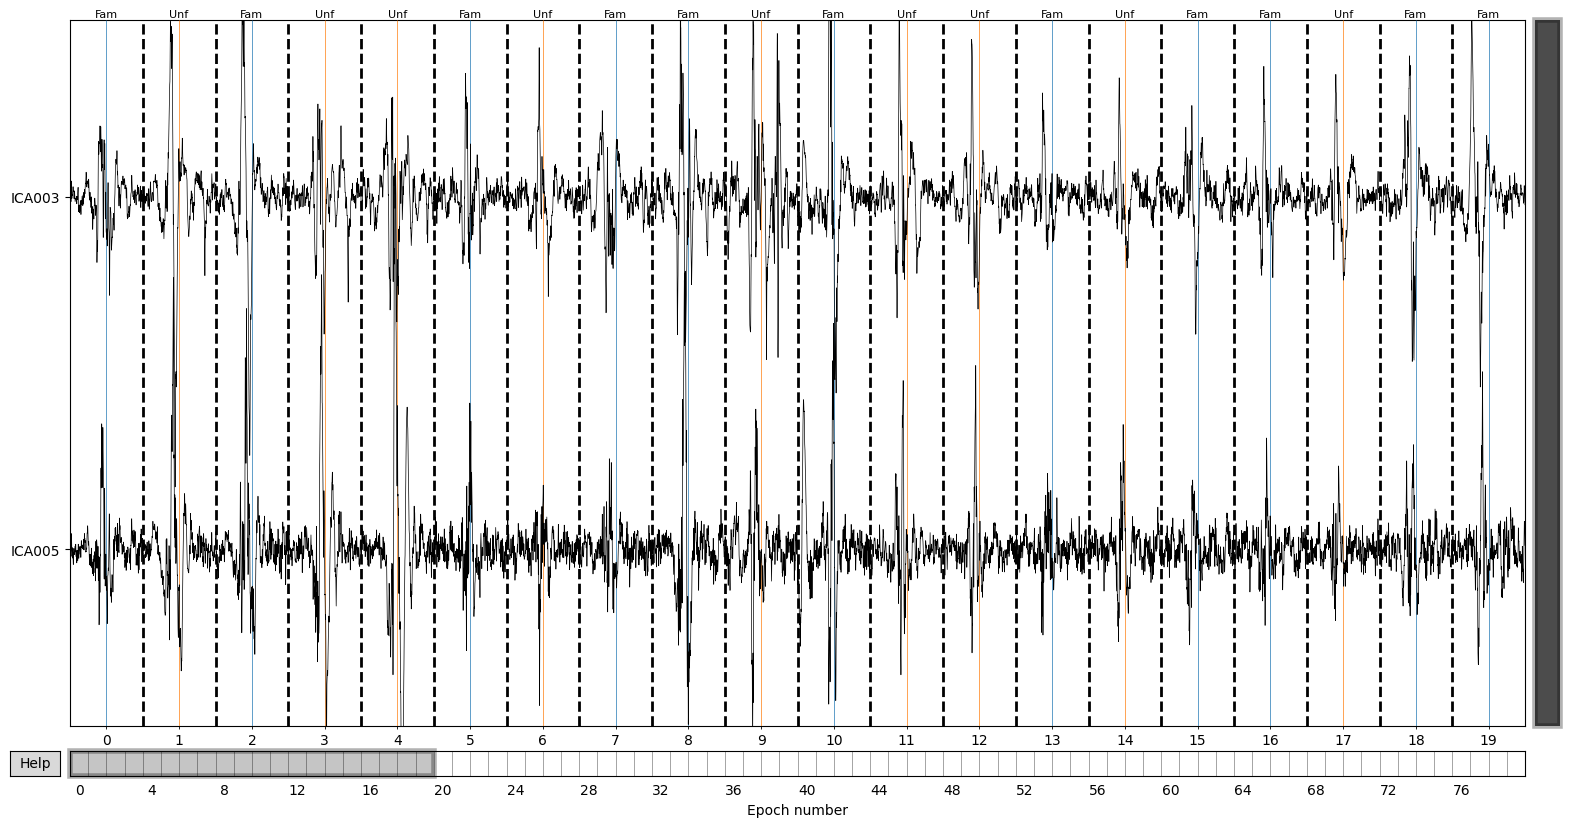

Plotting ICA properties...
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
80 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
80 matching events found
No baseline correction applied
0 projection items activated


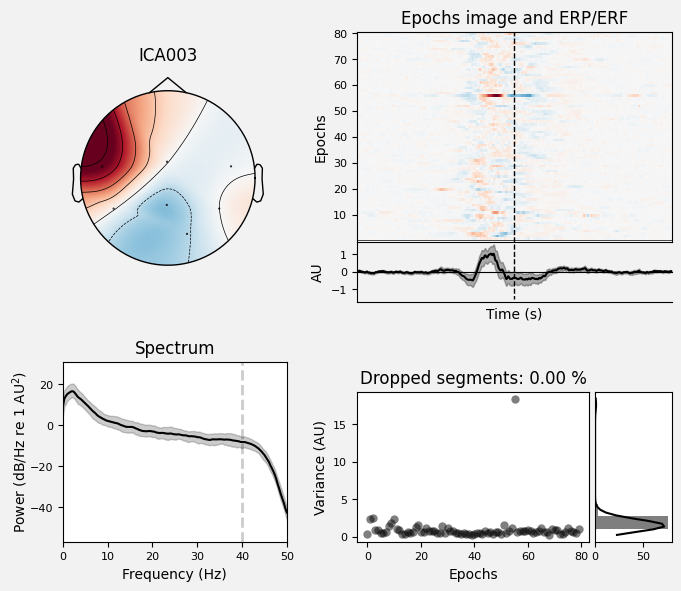

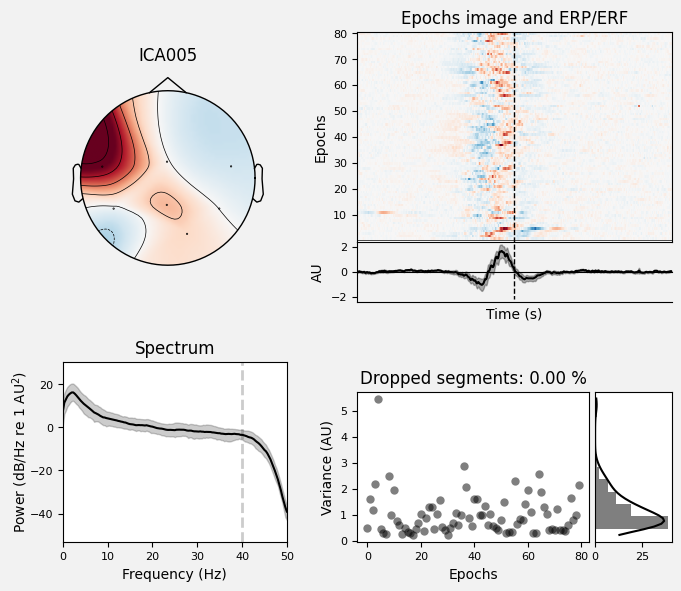

Inspect the plots to identify artifact components.
Set ica.exclude = [list of component indices] to exclude them.

Review the component plots above.
Identify artifact components (blinks, eye movements, muscle, etc.)


In [351]:
## Step 4b: Inspect ICA Components
if ica is not None:
    # Plot ICA components for inspection
    plot_ica_components(ica, epochs_for_ica, components_to_plot=[3, 5])
    
    # # Plot specifically for movement trials
    # epochs_move = epochs['Mov']
    # if len(epochs_move) > 0:
    #     print("Plotting ICA properties for movement trials...")
    #     plot_ica_components(ica, epochs_move, plot_ica_components=False, plot_ica_sources=True, components_to_plot=[0, 1, 2])
    
        
    print("Review the component plots above.")
    print("Identify artifact components (blinks, eye movements, muscle, etc.)")
else:
    print("ICA was not fitted (skipped or not yet run)")

In [352]:
## Step 4c: Set ICA Components to Exclude
# Set the component indices to exclude based on inspection
# Example: ica.exclude = [0, 1, 2]  # Exclude components 0, 1, and 2, or exclude = "None"
use_config = False
exclude = [0, 1, 2, 3, 4]

if ica is not None:
    # Use components from config or set manually
    if use_config:
        ica.exclude = preprocessing_config['ica']['exclude_components']
    else: 
        ica.exclude = exclude
    print(f"Components to exclude: {ica.exclude}")
    if not ica.exclude:
        print("No components set for exclusion")
else:
    print("ICA was not fitted (skipped)")

Components to exclude: [0, 1, 2, 3, 4]


In [353]:
## Step 4d: Apply ICA to Remove Artifacts
epochs_pre_ica = epochs.copy()  # Keep a copy before ICA for comparison. Uncomment if re-trying
if ica is not None and ica.exclude is not None:
    epochs = apply_ica(epochs_pre_ica, ica)
elif ica is None:
    print("ICA was not fitted (skipped)")
else:
    print("No components to exclude.")

Applying ICA to Remove Artifacts
Excluding components: [0, 1, 2, 3, 4]
Applying ICA to remove artifacts from original epochs...
Applying ICA to Epochs instance
    Transforming to ICA space (7 components)
    Zeroing out 5 ICA components
    Transforming to ICA space (7 components)
    Zeroing out 5 ICA components
    Projecting back using 7 PCA components
ICA artifact removal complete



In [354]:
## Step 5: Re-reference to REST
if preprocessing_config['rest']['apply']:
    epochs, forward = apply_rest_reference(epochs)
else:
    print("="*60)
    print("STEP 5: REST Re-referencing - SKIPPED")
    print("="*60 + "\n")
    forward = None

Re-referencing to REST (Infinite Reference)
Applying REST re-referencing...
Creating forward model for REST...
Fitted sphere radius:         88.3 mm
Origin head coordinates:      -1.5 3.7 54.5 mm
Origin device coordinates:    -1.5 3.7 54.5 mm

Equiv. model fitting -> RV = 0.00347662 %%
mu1 = 0.944829    lambda1 = 0.13688
mu2 = 0.667743    lambda2 = 0.683669
mu3 = -0.293043    lambda3 = -0.0101793
Set up EEG sphere model with scalp radius    88.3 mm

Sphere                : origin at (-1.5 3.7 54.5) mm
              radius  : 79.4 mm
grid                  : 15.0 mm
mindist               : 5.0 mm
Exclude               : 30.0 mm

Setting up the sphere...
Surface CM = (  -1.5    3.7   54.5) mm
Surface fits inside a sphere with radius   79.4 mm
Surface extent:
    x =  -80.9 ...   77.9 mm
    y =  -75.7 ...   83.2 mm
    z =  -24.9 ...  134.0 mm
Grid extent:
    x =  -90.0 ...   90.0 mm
    y =  -90.0 ...   90.0 mm
    z =  -30.0 ...  135.0 mm
2028 sources before omitting any.
587 sources a

C:\Users\doubl\AppData\Local\Temp\ipykernel_13428\3324133446.py:35: RuntimeWarning: Only 8 head digitization points of the specified kinds ("eeg", "extra",), fitting may be inaccurate
  sphere = mne.make_sphere_model("auto", "auto", epochs.info)


Finished.
Forward model created
EEG channel type selected for re-referencing
Applying REST reference.
Applying a custom ('EEG',) reference.
    7 out of 7 channels remain after picking
Forward model created
EEG channel type selected for re-referencing
Applying REST reference.
Applying a custom ('EEG',) reference.
    7 out of 7 channels remain after picking
REST re-referencing complete



In [355]:
## Step 6: Baseline Correction
epochs = apply_baseline_correction(
    epochs,
    baseline_window=preprocessing_config['baseline']['window']
)

Baseline Correction
Applying baseline correction using window: -1 to -0.7 s
Applying baseline correction (mode: mean)
Baseline correction complete

Baseline correction complete



In [356]:
## Step 7: Reject and Substitute Channels per Trial
epochs, bad_channels_per_trial = reject_bad_trials(
    epochs,
    amp_thresh=preprocessing_config['rejection']['amp_thresh'],
    baseline_window=preprocessing_config['rejection']['baseline_window'],
    erp_window=preprocessing_config['rejection']['erp_window'],
    n250_channels=preprocessing_config['rejection']['n250_channels'],
    p300_channels=preprocessing_config['rejection']['p300_channels'],
    rejection_threshold=preprocessing_config['rejection']['rejection_threshold']
)

Rejecting and Substituting Channels per Trial
Rejection threshold: 200 µV
Baseline window: [-1, -0.7]
ERP window: [0.1, 0.65]
Trial rejection if >50% of component channels are bad

N250 channels (3): ['P7', 'P8', 'O2']
P300 channels (2): ['Cz', 'Pz']

Trials to reject: 3 of 80
Trials with bad channels (but not rejected): 66

Rejected trials:
  Trial 4 (Unf): 6 bad channels | N250: 2/3 | P300: 2/2
  Trial 66 (Unf): 5 bad channels | N250: 2/3 | P300: 1/2
  Trial 78 (Fam): 6 bad channels | N250: 2/3 | P300: 2/2

Bad channels across trials:
  Cz: 3 trials
  P7: 4 trials
  P8: 3 trials
  Pz: 8 trials
  T7: 69 trials
  T8: 21 trials
Dropped 3 epochs: 4, 66, 78

Final: 77 good trials remaining


Final: 77 good trials remaining



In [357]:
## Preprocessing Complete - Summary
print("="*60)
print("PREPROCESSING PIPELINE COMPLETE")
print("="*60)
print(f"Final epochs: {len(epochs)} trials")
print(f"Channels: {epochs.ch_names}")
print(f"Sampling rate: {epochs.info['sfreq']} Hz")
print(f"Time range: {epochs.tmin} to {epochs.tmax} s")
print(f"Bad channels tracked: {len(bad_channels_per_trial)} trials with bad channels")
print("\nPreprocessing complete!")

PREPROCESSING PIPELINE COMPLETE
Final epochs: 77 trials
Channels: ['Cz', 'Pz', 'T7', 'T8', 'P7', 'P8', 'O2']
Sampling rate: 251.0 Hz
Time range: -1.49800796812749 to 1.49800796812749 s
Bad channels tracked: 69 trials with bad channels

Preprocessing complete!


In [358]:
## Save Preprocessed Epochs
if preprocessing_config['save']['save_epochs']:
    filename = preprocessing_config['save']['filename']
    epochs.save(filename, overwrite=True)
    print(f"Saved preprocessed epochs to: {filename}")
else:
    print("Saving skipped (save_epochs=False)")
    
# Save bad channels per trial
if preprocessing_config['save']['save_bad_channels'] and bad_channels_per_trial:
    filename = preprocessing_config['save']['bad_channels_filename']
    df_bad_channels = pd.DataFrame([
        {'trial_index': idx, 'bad_channels': ','.join(chs)}
        for idx, chs in bad_channels_per_trial.items()
    ])
    df_bad_channels.to_csv(filename, index=False)
    print(f"Saved bad channels per trial to: {filename}")
elif not bad_channels_per_trial:
    print("No channels per trial marked as bad.")

Saved preprocessed epochs to: experiment_data/exp3/eeg_exp3_preprocessed-epo.fif
Saved bad channels per trial to: experiment_data/exp3/exp3_bad_channels_per_trial.csv


## ERP Results/Visualization

Visualize and calculate the ERP results across trials.

This should allow for visualization of specific eye movement types and targets, averaging or selecting specific trials as necessary.

We also want to analyze N250 (T7,T8, P7,P8, O1,O2) and P300 (Pz,Cz) in particular. The plots will show a shaded region that is considered when averaging to find these components, and the scripts should print out the associated voltage level (Mean +/- SD)

#### Imports and Data Loading

In [359]:
import mne
from typing import Union, Sequence, Dict, Any
import numpy as np
import matplotlib.pyplot as plt

In [360]:
## Load epoch data
n_experiment = 3
run = ""

filename = data_dir + f"eeg_exp{n_experiment}{run}_preprocessed-epo.fif"
epochs = mne.read_epochs(filename, preload=True)

Reading c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\experiment_data\exp3\eeg_exp3_preprocessed-epo.fif ...
    Found the data of interest:
        t =   -1498.01 ...    1498.01 ms
        0 CTF compensation matrices available
    Found the data of interest:
        t =   -1498.01 ...    1498.01 ms
        0 CTF compensation matrices available
Not setting metadata
77 matching events found
No baseline correction applied
0 projection items activated


### Plotting Function

In [361]:
# Plot params
error_region_alpha = 0.2 # transparency for shaded error region
individual_trial_alpha = 0.4 # transparency for individual trials in grand plot

In [362]:
## Familiar vs Unfamiliar ERP plotter
def plot_familiar_vs_unfamiliar(
    epochs: mne.Epochs,
    component: str = "N250",
    familiar_selector: Union[None, str, Sequence[Union[str, int, bool]]] = None,
    unfamiliar_selector: Union[None, str, Sequence[Union[str, int, bool]]] = None,
    picks: Union[None, Sequence[str]] = None,
    time_window: tuple = (0, 0.6),
    analysis_window: tuple = None,
    average: bool = True,
    avg_method: str = "mean",  # 'mean' or 'median'
    smooth_ms: Union[None, float, int] = None,  # moving-average window (ms)
    title: Union[None, str] = None,
) -> tuple:
    """Plot familiar vs unfamiliar ERP components with optional averaging and smoothing."""
    
    # Validate inputs
    component = component.upper()
    if component not in {"N250", "P300"}:
        raise ValueError("component must be 'N250' or 'P300'")
    if avg_method.lower() not in {"mean", "median"}:
        raise ValueError("avg_method must be 'mean' or 'median'")

    # Component-specific parameters
    component_params = {
        "N250": {"peak_time": 0.250, "default_picks": ["T7", "T8", "P7", "P8", "O2"]},
        "P300": {"peak_time": 0.300, "default_picks": ["Pz", "Cz"]}
    }
    
    if not analysis_window:
        peak_time = component_params[component]["peak_time"]
        analysis_window = (peak_time - 0.050, peak_time + 0.050)
    else:
        peak_time = (analysis_window[0] + analysis_window[1]) / 2.0
    
    default_picks = component_params[component]["default_picks"]
    
    # Resolve channel picks
    def _resolve_picks(channel_candidates):
        """Convert channel names to available channels in epochs."""
        channel_map = {ch.upper(): ch for ch in epochs.ch_names}
        resolved = [channel_map[c.upper()] for c in channel_candidates if c.upper() in channel_map]
        if not resolved:
            raise RuntimeError(f"No requested channels found. Tried {channel_candidates}. Available: {epochs.ch_names}")
        return resolved

    picks = _resolve_picks(default_picks if picks is None else picks)

    # Get epoch labels
    event_id_to_label = {v: k for k, v in epochs.event_id.items()}
    epoch_labels = [event_id_to_label.get(code, str(code)) for code in epochs.events[:, 2]]

    def _get_epoch_indices(selector, auto_mask=None):
        """Get epoch indices based on selector and auto_mask."""
        n_epochs = len(epochs)
        
        # Use auto_mask if no selector provided
        if selector is None:
            return np.flatnonzero(auto_mask) if auto_mask is not None else np.arange(n_epochs)
        
        # Boolean mask
        if (isinstance(selector, (list, np.ndarray)) and len(selector) == n_epochs 
            and all(isinstance(x, (bool, np.bool_)) for x in selector)):
            return np.flatnonzero(selector)
        
        # Integer indices
        if (isinstance(selector, (list, np.ndarray)) and len(selector) > 0 
            and all(isinstance(x, (int, np.integer)) for x in selector)):
            indices = np.asarray(selector, dtype=int)
            if indices.min() < 0 or indices.max() >= n_epochs:
                raise IndexError("Selector indices out of range")
            return np.unique(indices)
        
        # String matching
        def _matches_label(search_string):
            search_string = search_string.lower()
            return np.array([search_string in str(label).lower() for label in epoch_labels], dtype=bool)
        
        if isinstance(selector, str):
            return np.flatnonzero(_matches_label(selector))
        
        if isinstance(selector, (list, tuple)) and all(isinstance(x, str) for x in selector):
            mask = np.zeros(n_epochs, dtype=bool)
            for s in selector:
                mask |= _matches_label(s)
            return np.flatnonzero(mask)
        
        raise TypeError("Unsupported selector type")

    # Auto-detect familiar/unfamiliar epochs
    # Labels are now 'Fam', 'Unf', or 'Mov'
    auto_familiar = np.array([str(label).lower() == "fam" for label in epoch_labels])
    auto_unfamiliar = np.array([str(label).lower() == "unf" for label in epoch_labels])

    familiar_indices = _get_epoch_indices(familiar_selector, auto_familiar)
    unfamiliar_indices = _get_epoch_indices(unfamiliar_selector, auto_unfamiliar)
    
    if familiar_indices.size == 0:
        raise ValueError("No familiar epochs selected")
    if unfamiliar_indices.size == 0:
        raise ValueError("No unfamiliar epochs selected")

    # Extract and prepare data
    tmin, tmax = time_window
    familiar_epochs = epochs[familiar_indices].copy().pick(picks=picks).crop(tmin=tmin, tmax=tmax)
    unfamiliar_epochs = epochs[unfamiliar_indices].copy().pick(picks=picks).crop(tmin=tmin, tmax=tmax)

    sfreq = float(familiar_epochs.info.get('sfreq', epochs.info.get('sfreq', 1.0)))

    def _smooth_data(data: np.ndarray, window_size: int) -> np.ndarray:
        """Apply moving average smoothing to data."""
        if window_size <= 1:
            return data
        
        kernel = np.ones(window_size, dtype=float) / window_size
        
        if data.ndim == 1:
            return np.convolve(data, kernel, mode='same')
        
        return np.apply_along_axis(lambda x: np.convolve(x, kernel, mode='same'), 
                                 axis=1, arr=data)

    # Calculate smoothing window
    smooth_window = 0
    if smooth_ms is not None:
        smooth_window = int(round(float(smooth_ms) * sfreq / 1000.0))
        if smooth_window < 1:
            smooth_window = 0
        # Prefer odd window size for symmetric smoothing
        if smooth_window % 2 == 0 and smooth_window > 1:
            smooth_window += 1

    # Get data (mean across channels)
    familiar_data = familiar_epochs.get_data().mean(axis=1)  # (n_familiar, n_times)
    unfamiliar_data = unfamiliar_epochs.get_data().mean(axis=1)  # (n_unfamiliar, n_times)
    
    times = familiar_epochs.times

    # Create plot
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # Plot individual trials or averages
    if not average:
        # Apply smoothing to individual trials if requested
        if smooth_window > 1:
            familiar_data_smoothed = _smooth_data(familiar_data, smooth_window)
            unfamiliar_data_smoothed = _smooth_data(unfamiliar_data, smooth_window)
        else:
            familiar_data_smoothed = familiar_data
            unfamiliar_data_smoothed = unfamiliar_data
            
        # Plot individual trials
        for trial in familiar_data_smoothed:
            ax.plot(times, trial * 1e6, color="#1f77b4", alpha=individual_trial_alpha, linewidth=0.8)
        for trial in unfamiliar_data_smoothed:
            ax.plot(times, trial * 1e6, color="#d62728", alpha=individual_trial_alpha, linewidth=0.8)
        
        # Calculate averages for the lines
        familiar_avg = familiar_data_smoothed.mean(axis=0)
        unfamiliar_avg = unfamiliar_data_smoothed.mean(axis=0)
        
        familiar_label = "Familiar"
        unfamiliar_label = "Unfamiliar"
    else:  
        # Apply smoothing to all trials first
        if smooth_window > 1:
            familiar_data_smoothed = _smooth_data(familiar_data, smooth_window)
            unfamiliar_data_smoothed = _smooth_data(unfamiliar_data, smooth_window)
        else:
            familiar_data_smoothed = familiar_data
            unfamiliar_data_smoothed = unfamiliar_data
        
        # For median averaging, smooth the median waveform instead of individual trials
        if avg_method.lower() == 'median':
            familiar_median = np.median(familiar_data, axis=0)
            unfamiliar_median = np.median(unfamiliar_data, axis=0)
            
            if smooth_window > 1:
                familiar_avg = _smooth_data(familiar_median, smooth_window)
                unfamiliar_avg = _smooth_data(unfamiliar_median, smooth_window)
            else:
                familiar_avg = familiar_median
                unfamiliar_avg = unfamiliar_median
            
            # Calculate standard error from smoothed median data
            familiar_sem = familiar_data_smoothed.std(axis=0) / np.sqrt(len(familiar_data_smoothed))
            unfamiliar_sem = unfamiliar_data_smoothed.std(axis=0) / np.sqrt(len(unfamiliar_data_smoothed))
        else:
            familiar_avg = familiar_data_smoothed.mean(axis=0)
            unfamiliar_avg = unfamiliar_data_smoothed.mean(axis=0)
            
            # Calculate standard error from smoothed data for error bars
            familiar_sem = familiar_data_smoothed.std(axis=0) / np.sqrt(len(familiar_data_smoothed))
            unfamiliar_sem = unfamiliar_data_smoothed.std(axis=0) / np.sqrt(len(unfamiliar_data_smoothed))
        
        # Add shaded error bars based on smoothed data
        ax.fill_between(times, 
                       (familiar_avg - familiar_sem) * 1e6, 
                       (familiar_avg + familiar_sem) * 1e6, 
                       color="#1f77b4", alpha=error_region_alpha)
        ax.fill_between(times, 
                       (unfamiliar_avg - unfamiliar_sem) * 1e6, 
                       (unfamiliar_avg + unfamiliar_sem) * 1e6, 
                       color="#d62728", alpha=error_region_alpha)

        familiar_label = f"Familiar ({avg_method})"
        unfamiliar_label = f"Unfamiliar ({avg_method})"

    # Plot average lines
    ax.plot(times, familiar_avg * 1e6, color="#1f77b4", linewidth=2.0, label=familiar_label)
    ax.plot(times, unfamiliar_avg * 1e6, color="#d62728", linewidth=2.0, label=unfamiliar_label)

    # Add component markers
    ax.axvline(peak_time, color="k", linestyle="--", linewidth=1.2, 
               label=f"{component} ({int(peak_time*1000)} ms)")
    ax.axvspan(analysis_window[0], analysis_window[1], color="k", alpha=0.10)

    # Format plot
    ax.set_xlim(tmin, tmax)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (µV)")
    
    if title:
        ax.set_title(title)
    else:
        ax.set_title(f"{component} Familiarity ERP ({', '.join(picks)})")
        
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.2)

    # Calculate statistics in analysis window (unsmoothed data)
    in_window_mask = (times >= analysis_window[0]) & (times <= analysis_window[1])
        
    familiar_values = familiar_data[:, in_window_mask].mean(axis=1) * 1e6
    unfamiliar_values = unfamiliar_data[:, in_window_mask].mean(axis=1) * 1e6

    stats = {
        "component": component,
        "avg_method": avg_method.lower(),
        "smooth_ms": float(smooth_ms) if smooth_ms is not None else None,
        "window_s": list(analysis_window),
        "channels": list(picks),
        "Familiar": {
            "n": int(familiar_data.shape[0]), 
            "mean_uV": float(np.mean(familiar_values)), 
            "sd_uV": float(np.std(familiar_values, ddof=1)) if familiar_values.size > 1 else float("nan")
        },
        "Unfamiliar": {
            "n": int(unfamiliar_data.shape[0]), 
            "mean_uV": float(np.mean(unfamiliar_values)), 
            "sd_uV": float(np.std(unfamiliar_values, ddof=1)) if unfamiliar_values.size > 1 else float("nan")
        },
    }

    # Print summary
    print(f"{component} analysis:")
    print(f"  Window: {analysis_window[0]:.3f}-{analysis_window[1]:.3f}s")
    print(f"  Channels: {picks}")
    print(f"  Method: {stats['avg_method']}, Smoothing: {stats['smooth_ms']}ms")
    print(f"  Familiar: n={stats['Familiar']['n']}, mean={stats['Familiar']['mean_uV']:.2f} µV, "
          f"sd={stats['Familiar']['sd_uV']:.2f} µV" if familiar_values.size > 1 else "NA")
    print(f"  Unfamiliar: n={stats['Unfamiliar']['n']}, mean={stats['Unfamiliar']['mean_uV']:.2f} µV, "
          f"sd={stats['Unfamiliar']['sd_uV']:.2f} µV" if unfamiliar_values.size > 1 else "NA")

    plt.show()
    return fig, stats

### N250 ERP

#### Parieto-occipital channels averaged (N250, fusiform)

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['P7', 'P8', 'O2']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=39, mean=8.59 µV, sd=21.52 µV
  Unfamiliar: n=38, mean=1.85 µV, sd=17.40 µV


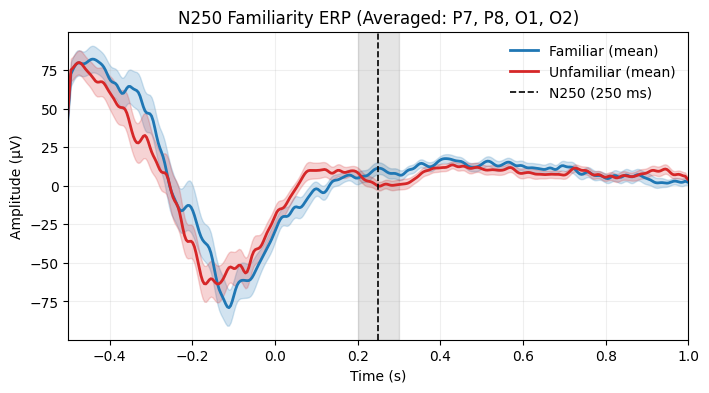

In [363]:
## N250 (single trials overlay)
fig, stats = plot_familiar_vs_unfamiliar(
    epochs,
    component="N250",
    picks=["P7", "P8", "O1", "O2"],
    time_window=(-0.5, 1),
    average=True,
    smooth_ms=20,
    avg_method="mean",
    title="N250 Familiarity ERP (Averaged: P7, P8, O1, O2)",
)

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['P7', 'P8', 'O2']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=39, mean=8.59 µV, sd=21.52 µV
  Unfamiliar: n=38, mean=1.85 µV, sd=17.40 µV


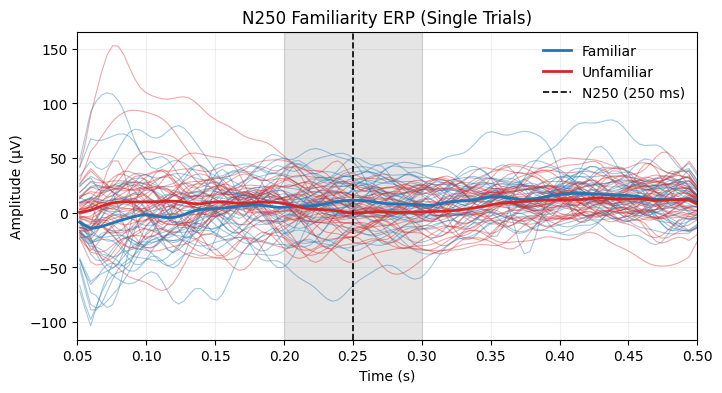

In [364]:
## N250 (single trials overlay)
fig, stats = plot_familiar_vs_unfamiliar(
    epochs,
    component="N250",
    picks=["P7", "P8", "O1", "O2"],
    time_window=(0.05, 0.5),
    average=False,
    smooth_ms=20,
    avg_method="mean",
    title="N250 Familiarity ERP (Single Trials)",
)

### P300 ERP

#### Midline channels averaged (P300)

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Pz', 'Cz']
  Method: mean, Smoothing: 10.0ms
  Familiar: n=39, mean=4.46 µV, sd=13.55 µV
  Unfamiliar: n=38, mean=-0.95 µV, sd=17.25 µV


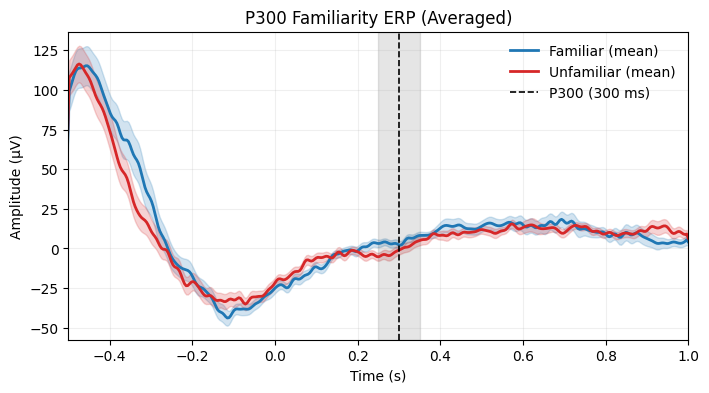

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 10.0, 'window_s': [0.25, 0.35], 'channels': ['Pz', 'Cz'], 'Familiar': {'n': 39, 'mean_uV': 4.461663803016135, 'sd_uV': 13.550503076058064}, 'Unfamiliar': {'n': 38, 'mean_uV': -0.9518758050537719, 'sd_uV': 17.252619695785572}}


In [365]:
## Plot P300 familiar vs unfamiliar (averaged Pz, all valid trials)
fig, stats = plot_familiar_vs_unfamiliar(
    epochs,
    component="P300",
    picks=["Pz", "Cz"],
    time_window=(-0.5, 1.0),
    average=True,
    smooth_ms=10,
    avg_method="mean",
    title="P300 Familiarity ERP (Averaged)",
)
print(stats)

#### Pz Only

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Pz']
  Method: mean, Smoothing: 10.0ms
  Familiar: n=39, mean=-1.68 µV, sd=16.76 µV
  Unfamiliar: n=38, mean=-3.69 µV, sd=21.56 µV


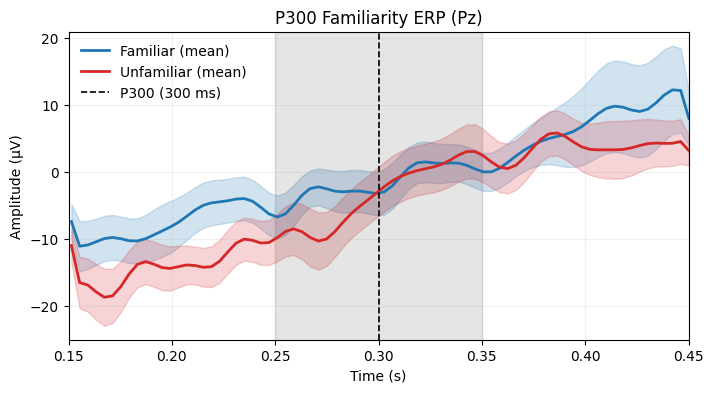

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 10.0, 'window_s': [0.25, 0.35], 'channels': ['Pz'], 'Familiar': {'n': 39, 'mean_uV': -1.6844341425499174, 'sd_uV': 16.763540714695417}, 'Unfamiliar': {'n': 38, 'mean_uV': -3.69177540817807, 'sd_uV': 21.562615821892972}}


In [366]:
## Plot P300 familiar vs unfamiliar (averaged Pz, all valid trials)
fig, stats = plot_familiar_vs_unfamiliar(
    epochs,
    component="P300",
    picks=["Pz"],
    time_window=(0.15, 0.45),
    average=True,
    smooth_ms=10,
    avg_method="mean",
    title="P300 Familiarity ERP (Pz)",
)
print(stats)

#### Cz Only

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Cz']
  Method: mean, Smoothing: 10.0ms
  Familiar: n=39, mean=10.61 µV, sd=19.76 µV
  Unfamiliar: n=38, mean=1.79 µV, sd=18.20 µV


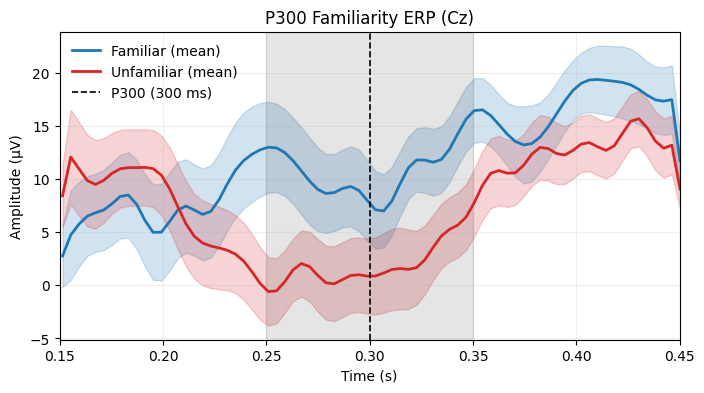

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 10.0, 'window_s': [0.25, 0.35], 'channels': ['Cz'], 'Familiar': {'n': 39, 'mean_uV': 10.607761748582188, 'sd_uV': 19.75564885783866}, 'Unfamiliar': {'n': 38, 'mean_uV': 1.788023798070526, 'sd_uV': 18.196297009938327}}


In [367]:
## Plot P300 familiar vs unfamiliar (averaged Cz, all valid trials)
fig, stats = plot_familiar_vs_unfamiliar(
    epochs,
    component="P300",
    picks=["Cz"],
    time_window=(0.15, 0.45),
    average=True,
    smooth_ms=10,
    avg_method="mean",
    title="P300 Familiarity ERP (Cz)",
)
print(stats)

# Feature Extraction

Extract statistical features of ERP for specific windows and channels.

**Note:** Use the preprocessed epochs from the pipeline above. The `bad_channels_per_trial` dictionary from preprocessing will be used to substitute bad channels with component averages during feature extraction.

Extract statistical features of ERP for specific windows and channels.

Statistical features:
- Mean voltage
- Median voltage
- Max voltage
- Minimum voltage
- Peak-to-peak amplitude
- Standard deviation
- Skewness
- Area under the curve
- Kurtosis


In [368]:
# Set experiment number and data directory
n_experiment = 3
run = ""   # run in a single experiment session: '', 'A', 'B', etc.
data_dir = f'experiment_data/exp{n_experiment}/'

##### Imports and Data Loading

In [369]:
import mne
from typing import Union, Sequence, Dict, Any
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

In [370]:
## Load epoch data
filename = data_dir + f"eeg_exp{n_experiment}{run}_preprocessed-epo.fif"
epochs = mne.read_epochs(filename, preload=True)

Reading c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\experiment_data\exp3\eeg_exp3_preprocessed-epo.fif ...
    Found the data of interest:
        t =   -1498.01 ...    1498.01 ms
        0 CTF compensation matrices available
Not setting metadata
77 matching events found
No baseline correction applied
0 projection items activated


##### Feature Extraction Function

In [371]:
## Epoch feature extraction function 
def extract_epoch_features(epochs, ch_windows):
    sfreq = float(epochs.info.get('sfreq', 250))

    # Select channels present in epochs
    name_map = {ch.upper(): ch for ch in epochs.ch_names}
    selected = {}
    for ch, win in ch_windows.items():
        if ch.upper() in name_map:
            selected[name_map[ch.upper()]] = win
    if not selected:
        raise RuntimeError(f"None of target channels {list(ch_windows.keys())} found in epochs: {epochs.ch_names}")

    X = epochs.get_data()  # (n_epochs, n_channels, n_times)
    ch_idx = {ch: epochs.ch_names.index(ch) for ch in selected.keys()}

    # Epoch condition labels from event IDs
    id_map = {v: k for k, v in epochs.event_id.items()}
    conditions = [id_map.get(code, str(code)) for code in epochs.events[:, 2]]

    # Pre-compute sample index ranges per channel window
    idx_windows = {}
    for ch, (t0, t1) in selected.items():
        i0, i1 = epochs.time_as_index([float(t0), float(t1)])
        if i0 > i1:  # Flip if reversed
            i0, i1 = i1, i0
        idx_windows[ch] = (int(i0), int(i1))

    stat_order = ['mean', 'median', 'max', 'min', 'ptp', 'std', 'skew', 'auc', 'kurtosis']

    # Define N250 and P300 channel groups
    n250_channels = ['P7', 'P8', 'O1', 'O2']
    p300_channels = ['Cz', 'Pz']
    
    # Identify present channels for each group
    n250_present = [ch for ch in n250_channels if ch in selected.keys()]
    p300_present = [ch for ch in p300_channels if ch in selected.keys()]
    
    # Identify absent channels for each group
    n250_absent = [ch for ch in n250_channels if ch not in selected.keys()]
    p300_absent = [ch for ch in p300_channels if ch not in selected.keys()]

    rows = []
    for epoch in range(X.shape[0]):
        row = {}
        for ch, (i0, i1) in idx_windows.items():
            x = X[epoch, ch_idx[ch], i0:i1 + 1] * 1e6  # convert to µV
            if x.size == 0:
                vals = {s: float('nan') for s in stat_order}
            else:
                vals = {
                    'mean': float(np.mean(x)),
                    'median': float(np.median(x)),
                    'max': float(np.max(x)),
                    'min': float(np.min(x)),
                    'ptp': float(np.ptp(x)),
                    'std': float(np.std(x, ddof=0)),
                    'skew': float(skew(x, bias=False)) if x.size > 2 else float('nan'),
                    'auc': float(np.trapezoid(x, dx=1.0 / sfreq)),  # integrate using trapezoidal rule
                    'kurtosis': float(kurtosis(x, fisher=False, bias=False)) if x.size > 3 else float('nan'),
                }
            for s in stat_order:
                row[f"{ch}_{s}"] = vals[s]
        
        # Compute averaged features for N250
        if n250_present:
            for s in stat_order:
                values = [row[f"{ch}_{s}"] for ch in n250_present if f"{ch}_{s}" in row]
                if values:
                    row[f"N250avg_{s}"] = float(np.nanmean(values))
                    for ch in n250_absent:
                        row[f"{ch}_{s}"] = float(np.nanmean(values)) # impute missing N250 channels with average
                else:
                    row[f"N250avg_{s}"] = float('nan')
                    for ch in n250_absent:
                        row[f"{ch}_{s}"] = float('nan')
        
        # Compute averaged features for P300
        if p300_present:
            for s in stat_order:
                values = [row[f"{ch}_{s}"] for ch in p300_present if f"{ch}_{s}" in row]
                if values:
                    row[f"P300avg_{s}"] = float(np.nanmean(values))
                    for ch in p300_absent:
                        row[f"{ch}_{s}"] = float(np.nanmean(values)) # impute missing P300 channels with average
                else:
                    row[f"P300avg_{s}"] = float('nan')
                    for ch in p300_absent:
                        row[f"{ch}_{s}"] = float('nan')
        
        row['condition'] = conditions[epoch] if epoch < len(conditions) else None
        rows.append(row)

    df = pd.DataFrame(rows)

    # Order columns by channel then stat, condition first
    preferred_ch_order = ['Cz','Pz', 'P7', 'P8', 'O1','O2']
    # Build ordered columns following preferred channel order
    ordered_cols = []
    
    # Add individual channel columns in preferred order
    for ch in preferred_ch_order:
        if ch in selected.keys() or ch in n250_absent or ch in p300_absent:
            ordered_cols.extend([f"{ch}_{s}" for s in stat_order])
    
    # Add averaged N250 and P300 columns at the end
    if n250_present:
        ordered_cols.extend([f"N250avg_{s}" for s in stat_order])
    if p300_present:
        ordered_cols.extend([f"P300avg_{s}" for s in stat_order])

    cols = ['condition'] + [c for c in ordered_cols if c in df.columns]
    df = df[cols]
    return df

##### Run Feature Extraction

In [372]:
## Define windows for N250 and P300
win_n250 = (0.2, 0.3) # T8, P7, O2
win_p300 = (0.25, 0.35) # Cz

In [373]:
## Run feature extraction

# Channel window mapping
ch_windows = {
    'Cz': win_p300,
    'Pz': win_p300,
    'P7': win_n250,
    'P8': win_n250,
    'O1': win_n250,
    'O2': win_n250,
}

features_df = extract_epoch_features(epochs, ch_windows)
print(features_df.shape)
features_df.head(10)

(77, 73)


,condition,Cz_mean,Cz_median,Cz_max,Cz_min,Cz_ptp,Cz_std,Cz_skew,Cz_auc,Cz_kurtosis,...,N250avg_kurtosis,P300avg_mean,P300avg_median,P300avg_max,P300avg_min,P300avg_ptp,P300avg_std,P300avg_skew,P300avg_auc,P300avg_kurtosis
0,Fam,26.764760,24.362443,58.039779,-2.400666,60.440445,16.496948,0.087932,2.657336,2.062226,...,2.992052,-0.724392,-6.485378,37.403066,-36.969050,74.372116,21.596872,0.268448,-0.083785,2.035044
1,Unf,-4.156202,-8.651524,31.375126,-32.242344,63.617470,18.717124,0.573394,-0.454795,2.360514,...,2.234911,-0.301335,-2.215429,23.824270,-21.284414,45.108684,13.413939,0.204813,-0.037444,2.136277
2,Fam,-10.236204,-10.681199,27.542099,-42.344200,69.886299,19.690413,0.113310,-1.031981,2.170020,...,2.459001,7.824398,7.963691,41.536156,-23.647397,65.183554,17.202467,0.041823,0.791727,2.594595
3,Unf,-22.921269,-29.888542,-1.674582,-40.691204,39.016622,14.970698,0.317774,-2.297291,1.239246,...,2.285094,-5.435706,-8.566510,18.910651,-28.563528,47.474179,16.002550,0.138736,-0.546977,1.479175
4,Fam,12.025607,12.909037,26.858914,-11.233996,38.092910,9.482324,-0.897700,1.208392,3.781252,...,2.468043,-4.931935,-4.345786,5.888727,-19.725202,25.613928,6.459580,-0.356278,-0.478261,3.011002
5,Unf,26.340506,27.050535,51.108902,2.870590,48.238312,12.723108,0.122871,2.589822,2.369248,...,3.012416,-0.771790,-3.387916,28.619374,-22.946155,51.565529,14.856959,0.476163,-0.108098,2.375103
6,Fam,-18.611333,-16.044520,6.773289,-39.435505,46.208793,12.115005,0.003806,-1.862803,2.298364,...,2.577390,-8.584217,-7.613218,9.195181,-23.144885,32.340066,8.744137,0.107026,-0.863661,2.090016
7,Fam,-0.882012,0.209148,21.790844,-23.136165,44.927008,13.175173,0.092204,-0.134260,1.922220,...,1.994940,-2.726952,-2.379407,17.132440,-20.881103,38.013543,9.905961,0.230148,-0.287161,3.222898
8,Unf,-20.142280,-19.581545,-1.869924,-35.303314,33.433390,8.973616,-0.041459,-2.021423,2.206371,...,2.894743,-19.863312,-19.805690,-5.365030,-34.526303,29.161273,7.992063,-0.088920,-1.975718,2.161405
9,Fam,33.688877,31.860593,45.952365,18.437424,27.514941,7.582624,0.050282,3.374375,1.913575,...,1.856898,17.029620,16.632748,26.178442,4.852198,21.326244,5.736381,-0.240517,1.715112,2.243562


In [374]:
## Save features to CSV
out_dir = data_dir if 'data_dir' in globals() else f'experiment_data/exp{n_experiment}/'
out_path = out_dir + f'erp_exp{n_experiment}{run}_features.csv'
features_df.to_csv(out_path, index=False)
print(f"Saved features to {out_path}")

Saved features to experiment_data/exp3/erp_exp3_features.csv
